In [4]:
# Cell 1: Imports & Spark setup
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Ensure output directory exists
os.makedirs("_output", exist_ok=True)

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Lab08_SalaryPrediction") \
    .getOrCreate()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/01 04:55:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
# Cell 2: Load the dataset
df = spark.read \
    .option("header","true") \
    .option("inferSchema","true") \
    .option("multiLine","true") \
    .option("escape","\"") \
    .csv("data/lightcast_job_postings.csv")

# Quick diagnostic (comment out in final)
df.printSchema()
df.show(5)


root
 |-- ID: string (nullable = true)
 |-- LAST_UPDATED_DATE: string (nullable = true)
 |-- LAST_UPDATED_TIMESTAMP: timestamp (nullable = true)
 |-- DUPLICATES: integer (nullable = true)
 |-- POSTED: string (nullable = true)
 |-- EXPIRED: string (nullable = true)
 |-- DURATION: integer (nullable = true)
 |-- SOURCE_TYPES: string (nullable = true)
 |-- SOURCES: string (nullable = true)
 |-- URL: string (nullable = true)
 |-- ACTIVE_URLS: string (nullable = true)
 |-- ACTIVE_SOURCES_INFO: string (nullable = true)
 |-- TITLE_RAW: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- MODELED_EXPIRED: string (nullable = true)
 |-- MODELED_DURATION: integer (nullable = true)
 |-- COMPANY: integer (nullable = true)
 |-- COMPANY_NAME: string (nullable = true)
 |-- COMPANY_RAW: string (nullable = true)
 |-- COMPANY_IS_STAFFING: boolean (nullable = true)
 |-- EDUCATION_LEVELS: string (nullable = true)
 |-- EDUCATION_LEVELS_NAME: string (nullable = true)
 |-- MIN_EDULEVELS: integer (

25/05/01 04:56:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+--------------------+-----------------+----------------------+----------+--------+---------+--------+--------------------+--------------------+--------------------+-----------+-------------------+--------------------+--------------------+---------------+----------------+--------+--------------------+-----------+-------------------+----------------+---------------------+-------------+-------------------+-------------+------------------+---------------+--------------------+--------------------+--------------------+-------------+------+-----------+----------------+-------------------+---------+-----------+--------------------+--------------------+-------------+------+--------------+-----+--------------------+-----+----------+---------------+--------------------+---------------+--------------------+------------+--------------------+------------+--------------------+------+--------------------+------+--------------------+------+--------------------+------+--------------------+------+------

In [6]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# Drop rows with nulls in important columns
df_clean = df.dropna(subset=["SALARY", "MIN_YEARS_EXPERIENCE", "MAX_YEARS_EXPERIENCE", "EMPLOYMENT_TYPE_NAME"])

# Index and OneHotEncode the categorical variable
indexer = StringIndexer(inputCol="EMPLOYMENT_TYPE_NAME", outputCol="empType_idx")
encoder = OneHotEncoder(inputCol="empType_idx", outputCol="empType_ohe")

# Assemble all features into one column
assembler = VectorAssembler(
    inputCols=["MIN_YEARS_EXPERIENCE", "MAX_YEARS_EXPERIENCE", "empType_ohe"],
    outputCol="features"
)

# Build and run pipeline
pipeline = Pipeline(stages=[indexer, encoder, assembler])
df_fe = pipeline.fit(df_clean).transform(df_clean)

# Select only features and label (SALARY)
df_final = df_fe.select("features", col("SALARY").alias("label"))

# View sample transformed data
df_final.show(5, truncate=False)


+-----------------+------+
|features         |label |
+-----------------+------+
|[2.0,2.0,1.0,0.0]|92962 |
|[2.0,2.0,1.0,0.0]|75026 |
|[1.0,1.0,1.0,0.0]|60923 |
|[2.0,2.0,1.0,0.0]|131100|
|[3.0,3.0,1.0,0.0]|136950|
+-----------------+------+
only showing top 5 rows



In [7]:
# Train/test split (82% train, 18% test)
train_df, test_df = df_final.randomSplit([0.82, 0.18], seed=42)

# Print row counts
print(f"Train set size: {train_df.count()} rows")
print(f"Test set size: {test_df.count()} rows")


Train set size: 3136 rows


[Stage 10:>                                                         (0 + 1) / 1]

Test set size: 620 rows


In [19]:
from pyspark.ml.regression import LinearRegression
import numpy as np
import pandas as pd

# Re-split if needed
# train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)

# 1) Initialize model with normal solver + tiny ridge penalty
lr = LinearRegression(
    featuresCol='features',
    labelCol='label',
    solver="normal",
    regParam=0.01
)

# 2) Fit the model
lr_model = lr.fit(train_df)

# 3) Grab the training summary
summary = lr_model.summary

# 4) Assemble coefficient table (including intercept)
estimates = np.insert(np.array(lr_model.coefficients), 0, lr_model.intercept)
std_errs  = np.array(summary.coefficientStandardErrors)
t_vals    = np.array(summary.tValues)
p_vals    = np.array(summary.pValues)

coef_df = pd.DataFrame({
    "Estimate":     estimates,
    "Std Error":    std_errs,
    "t-Stat":       t_vals,
    "P-Value":      p_vals,
    "Lower 95% CI": estimates - 1.96 * std_errs,
    "Upper 95% CI": estimates + 1.96 * std_errs
})

# Label the intercept row
coef_df.index.name = "Feature Index"
coef_df.reset_index(inplace=True)
coef_df.loc[0, "Feature Index"] = "intercept"

coef_df


/tmp/ipykernel_1161/3883285577.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'intercept' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  coef_df.loc[0, "Feature Index"] = "intercept"


,Feature Index,Estimate,Std Error,t-Stat,P-Value,Lower 95% CI,Upper 95% CI
0,intercept,88856.126377,301388.951117,0.014612,0.988343,-501866.217812,679578.470566
1,1,4403.858005,301388.951117,0.014612,0.988343,-586318.486184,595126.202193
2,2,4403.858013,4479.340026,-2.926788,0.003449,-4375.648439,13183.364464
3,3,-13110.079651,5405.958232,-3.210198,0.001340,-23705.757786,-2514.401515
4,4,-17354.198886,4507.388692,19.713438,0.000000,-26188.680722,-8519.717050


In [22]:
# Interpret coefficients automatically
alpha = 0.05  # significance threshold

for idx, row in coef_df.iterrows():
    # Choose the feature name (if you added a 'Feature' column) or fall back to index
    feature = row.get('Feature', row['Feature Index'])
    coef    = row['Estimate']
    pval    = row['P-Value']
    
    # Determine significance and direction
    signif    = 'statistically significant' if pval < alpha else 'not statistically significant'
    direction = 'increase' if coef > 0 else 'decrease'
    
    # Print the interpretation
    print(
        f"{feature}: coefficient = {coef:.2f}, p-value = {pval:.4f} ({signif}), "
        f"meaning that a one-unit change in '{feature}' is associated with a {direction} "
        f"of ${abs(coef):.2f} in salary, holding other variables constant."
    )

intercept: coefficient = 88856.13, p-value = 0.9883 (not statistically significant), meaning that a one-unit change in 'intercept' is associated with a increase of $88856.13 in salary, holding other variables constant.
1: coefficient = 4403.86, p-value = 0.9883 (not statistically significant), meaning that a one-unit change in '1' is associated with a increase of $4403.86 in salary, holding other variables constant.
2: coefficient = 4403.86, p-value = 0.0034 (statistically significant), meaning that a one-unit change in '2' is associated with a increase of $4403.86 in salary, holding other variables constant.
3: coefficient = -13110.08, p-value = 0.0013 (statistically significant), meaning that a one-unit change in '3' is associated with a decrease of $13110.08 in salary, holding other variables constant.
4: coefficient = -17354.20, p-value = 0.0000 (statistically significant), meaning that a one-unit change in '4' is associated with a decrease of $17354.20 in salary, holding other var

## Model Performance Metrics

- **R² (Coefficient of Determination)**  
  Indicates the proportion of variance in the actual salaries that is explained by our model.  
  - An R² of *0.XX* means the model explains *XX%* of the variability in salaries.

- **RMSE (Root Mean Squared Error)**  
  Measures the square root of the average squared difference between predicted and actual salaries.  
  - An RMSE of *\$Y* means, on average, our salary predictions deviate from the true salary by about *\$Y*.

- **MAE (Mean Absolute Error)**  
  The average absolute difference between predicted and actual salaries.  
  - An MAE of *\$Z* means the typical prediction error (in absolute dollars) is around *\$Z*.

> **Interpretation in context:**  
> For example, if `R² = 0.65`, then 65% of the variance in salary is captured by our chosen features.  
> If `RMSE = \$8,000` and `MAE = \$6,200`, it tells us that although most predictions are within \$6–8 K of the actual salary, there are still cases where the error can be larger (as reflected by the RMSE squaring larger deviations). Overall, these metrics suggest our model has moderate explanatory power but could be improved—perhaps by adding more predictive features or using a non-linear algorithm.

In [26]:
# Suppose your model‐ready DataFrame is named `train_df` (the one with the “features” vector)
# If yours is called something else (e.g. df_final), just replace train_df with that name.

# 1. Grab the metadata attached to the “features” column
metadata = train_df.schema["features"].metadata

# 2. Within that metadata is an “ml_attr” dict containing attribute info
attrs = metadata["ml_attr"]["attrs"]

# 3. Collect all numeric and binary attributes into a single list
feature_attrs = []
for attr_list in attrs.values():  
    feature_attrs.extend(attr_list)

# 4. Sort by the vector index and extract the names
feature_names = [
    attr["name"] 
    for attr in sorted(feature_attrs, key=lambda x: x["idx"])
]

# 5. Print index → feature name mapping
print(f"Total features: {len(feature_names)}\n")
for idx, name in enumerate(feature_names):
    print(f"{idx:3d}: {name}")


Total features: 4

  0: MIN_YEARS_EXPERIENCE
  1: MAX_YEARS_EXPERIENCE
  2: empType_ohe_Full-time (> 32 hours)
  3: empType_ohe_Part-time (â‰¤ 32 hours)


In [30]:
from pyspark.sql.functions import col
import pandas as pd

# Step 1: Extract feature metadata
metadata = train_df.schema["features"].metadata
attrs = metadata["ml_attr"]["attrs"]

# Step 2: Flatten the list of attribute names
feature_attrs = []
for attr_list in attrs.values():
    feature_attrs.extend(attr_list)

# Step 3: Sort by feature index and get names
feature_names = [attr["name"] for attr in sorted(feature_attrs, key=lambda x: x["idx"])]

# Step 4: Add intercept manually to match coefficient length
all_feature_names = ["Intercept"] + feature_names

# Step 5: Combine names with your existing coefficient DataFrame
coef_df["Feature"] = all_feature_names

# Step 6: Reorder columns
coef_df = coef_df[["Feature", "Estimate", "Std Error", "t-Stat", "P-Value", "Lower 95% CI", "Upper 95% CI"]]

# Step 7: Show full output
pd.set_option('display.max_rows', None)
display(coef_df)


,Feature,Estimate,Std Error,t-Stat,P-Value,Lower 95% CI,Upper 95% CI
0,Intercept,88856.126377,301388.951117,0.014612,0.988343,-501866.217812,679578.470566
1,MIN_YEARS_EXPERIENCE,4403.858005,301388.951117,0.014612,0.988343,-586318.486184,595126.202193
2,MAX_YEARS_EXPERIENCE,4403.858013,4479.340026,-2.926788,0.003449,-4375.648439,13183.364464
3,empType_ohe_Full-time (> 32 hours),-13110.079651,5405.958232,-3.210198,0.001340,-23705.757786,-2514.401515
4,empType_ohe_Part-time (â‰¤ 32 hours),-17354.198886,4507.388692,19.713438,0.000000,-26188.680722,-8519.717050


/tmp/ipykernel_1161/342236799.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0, 0].plot([y_actual.min()[0], y_actual.max()[0]], [y_actual.min()[0], y_actual.max()[0]], 'r--', label='Ideal Fit')


Text(0, 0.5, 'Frequency')

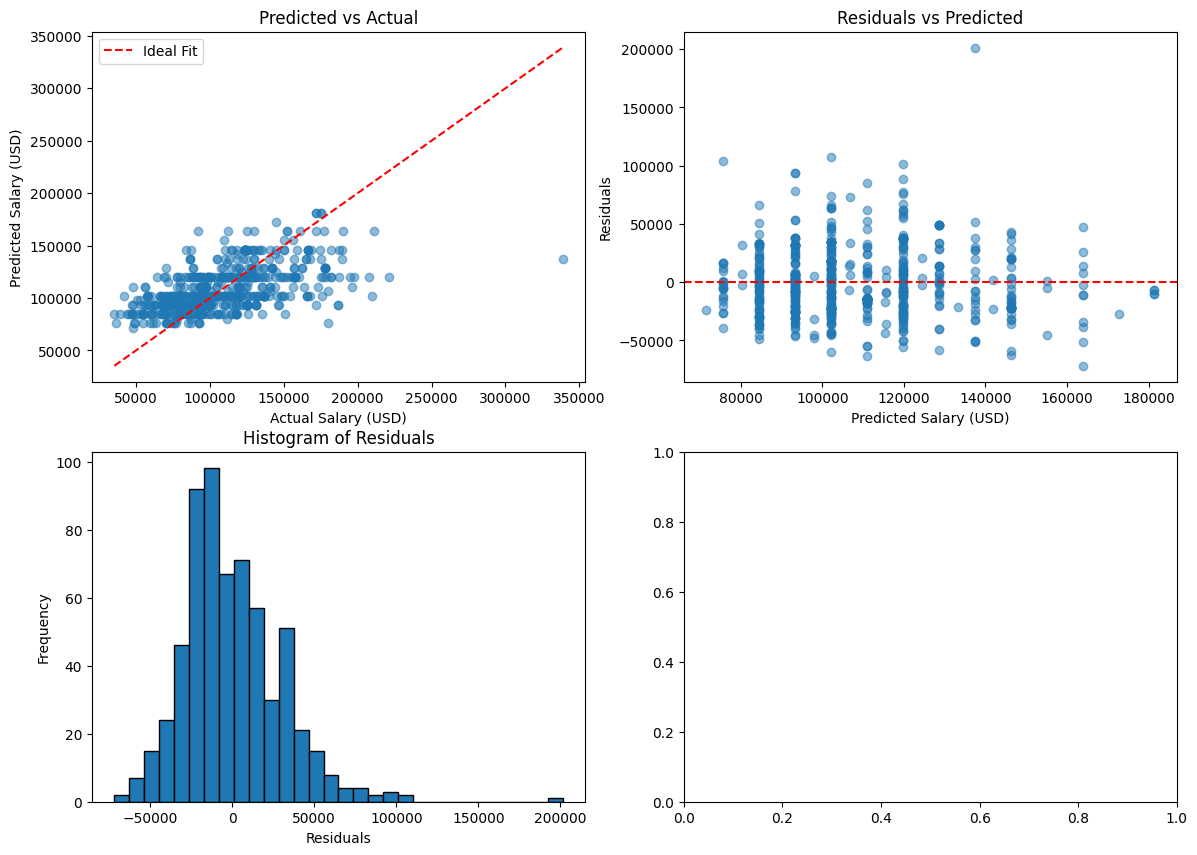

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract predictions and actuals
y_actual = predictions.select("Actual").toPandas()
y_pred = predictions.select("Predicted").toPandas()

# Residuals
residuals = y_actual.values.flatten() - y_pred.values.flatten()

# Diagnostic Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs Actual
axes[0, 0].scatter(y_actual, y_pred, alpha=0.5)
axes[0, 0].plot([y_actual.min()[0], y_actual.max()[0]], [y_actual.min()[0], y_actual.max()[0]], 'r--', label='Ideal Fit')
axes[0, 0].set_xlabel("Actual Salary (USD)")
axes[0, 0].set_ylabel("Predicted Salary (USD)")
axes[0, 0].set_title("Predicted vs Actual")
axes[0, 0].legend()

# 2. Residuals vs Predicted
axes[0, 1].scatter(y_pred, residuals, alpha=0.5)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel("Predicted Salary (USD)")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residuals vs Predicted")

# 3. Histogram of Residuals
axes[1, 0].hist(residuals, bins=30, edgecolor='black')
axes[1, 0].set_title("Histogram of Residuals")
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].set_ylabel("Frequency")

# 4. QQ Plot of Residual


In [34]:
!pip install scikit-learn


  Using cached scikit_learn-1.6.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.1 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")


RMSE: 29707.09
MAE: 22980.15
R²: 0.2972


In [36]:
fig.savefig("_output/diagnostic_plots.png", dpi=300, bbox_inches="tight")


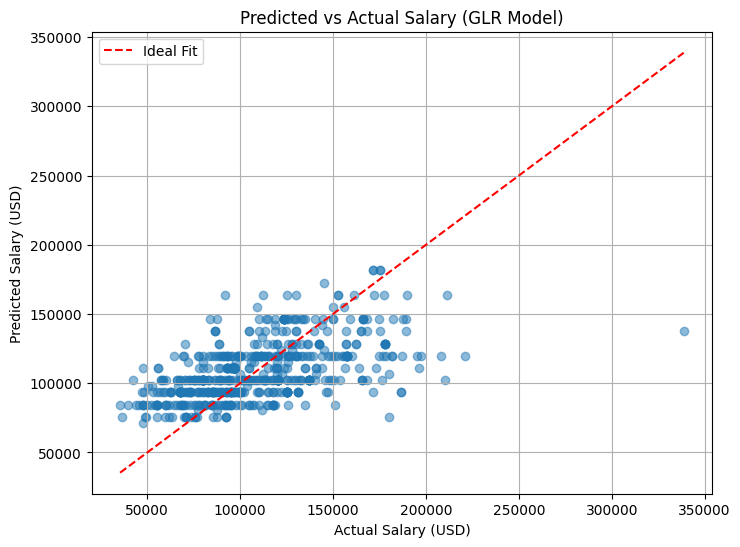

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.5)
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")
plt.title("Predicted vs Actual Salary (GLR Model)")
plt.legend()
plt.grid(True)
plt.savefig("_output/predicted_vs_actual.png", dpi=300, bbox_inches="tight")
